In [1]:
import matplotlib.pyplot as plt
import json
import sys
import os
from pathlib import Path
import numpy as np
import networkx as nx

from matplotlib.ticker import MaxNLocator
plt.rcParams.update({"font.size":13})

In [41]:
hamiltonian_class = "H4_linear"
geometries = [1.089, 2.067, 2.556, 4.022]

# hamiltonian_class = "H2O_OH"
# geometries = [0.958, 1.643, 2.5]

hamiltonians = list(Path("../hamiltonians/").glob(hamiltonian_class + "*"))
hamiltonian_names = sorted([q.name for q in hamiltonians])
print(hamiltonian_names)

bond_length = dict(zip(hamiltonian_names, geometries))
print(bond_length)

['H4_linear_d1.0890.chk', 'H4_linear_d2.0670.chk', 'H4_linear_d2.5560.chk', 'H4_linear_d4.0220.chk']
{'H4_linear_d1.0890.chk': 1.089, 'H4_linear_d2.0670.chk': 2.067, 'H4_linear_d2.5560.chk': 2.556, 'H4_linear_d4.0220.chk': 4.022}


In [42]:
p = Path("../outputs/quartets/")
quartet_data_paths = []
for name in hamiltonian_names:
    quartet_data_paths += list(p.glob("quartets_" + name + "*"))

quartet_data_paths = sorted(quartet_data_paths)
quartet_data_paths

[PosixPath('../outputs/quartets/quartets_H4_linear_d1.0890.chk_3bf40b'),
 PosixPath('../outputs/quartets/quartets_H4_linear_d1.0890.chk_4802ab'),
 PosixPath('../outputs/quartets/quartets_H4_linear_d1.0890.chk_61c9a5'),
 PosixPath('../outputs/quartets/quartets_H4_linear_d1.0890.chk_8132e0'),
 PosixPath('../outputs/quartets/quartets_H4_linear_d2.0670.chk_38cb0e'),
 PosixPath('../outputs/quartets/quartets_H4_linear_d2.0670.chk_401fb6'),
 PosixPath('../outputs/quartets/quartets_H4_linear_d2.0670.chk_86847c'),
 PosixPath('../outputs/quartets/quartets_H4_linear_d2.0670.chk_ecb257'),
 PosixPath('../outputs/quartets/quartets_H4_linear_d2.5560.chk_0f96c1'),
 PosixPath('../outputs/quartets/quartets_H4_linear_d2.5560.chk_151951'),
 PosixPath('../outputs/quartets/quartets_H4_linear_d2.5560.chk_4b0ca8'),
 PosixPath('../outputs/quartets/quartets_H4_linear_d2.5560.chk_6d2369'),
 PosixPath('../outputs/quartets/quartets_H4_linear_d4.0220.chk_19288c'),
 PosixPath('../outputs/quartets/quartets_H4_linear_

In [43]:
quartet_data = []
for qp in quartet_data_paths:
    with open(qp, "r") as fp:
        quartet_data.append(json.load(fp))

In [44]:
for q in quartet_data:
    g = nx.Graph(q["lowest_nc_quartets"])
    print(nx.is_tree(g))

False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False


In [45]:
no_opt_results = [q for q in quartet_data 
                  if (q["vars"]["optimization_mode"] is None)]

print(len(no_opt_results))

topm_results = [q for q in quartet_data 
                  if (q["vars"]["optimization_mode"] == "OO"
                     and q["vars"]["quartet_graph"] == "topm")]
print(len(topm_results))

matching_results = [q for q in quartet_data 
                  if (q["vars"]["optimization_mode"]=="OO"
                     and q["vars"]["quartet_graph"]=="matching"
                     and q["vars"]["initial_guess"] is None)]

print(len(matching_results))


complete_graph_results = [q for q in quartet_data 
                  if (q["vars"]["optimization_mode"]=="OO"
                     and q["vars"]["quartet_graph"]=="complete"
                     and q["vars"]["initial_guess"] is None)]

print(len(complete_graph_results))


4
4
4
4


In [48]:
def k_overlap(data):
    return [q["sector_data"]["K_overlap"] for q in data]


def k_en(data):
    return [q["sector_data"]["K_en"] for q in data]


def bo_energy(data):
    return np.array([q["sector_data"]["BO energy"] for q in data])


def fci_energy(data):
    return np.array([q["FCI energy"] for q in data])


def decoupled_energy(data):
    return np.array([q["sector_data"]["Decoupled_energy"] 
                                   for q in data])

def sector_count_en(data):
    sectors = [q["sector_data"]["Energy sectors"] for q in data]
    return [len(x) for x in sectors]


def sector_count_overlap(data):
    sectors = [q["sector_data"]["Overlap sectors"] for q in data]
    return [len(x) for x in sectors]


def nc_score(data):
    return [q["lowest_m_quartet_sum_opt"] for q in data]

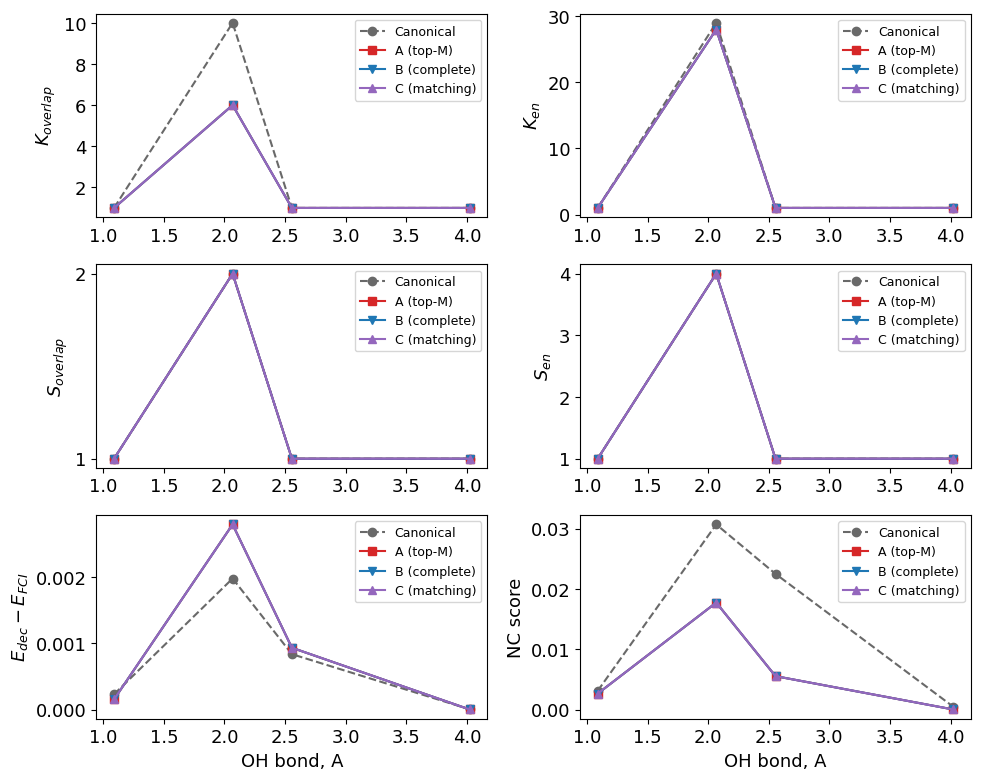

In [53]:
data_collections = (no_opt_results, topm_results, complete_graph_results, matching_results)
legend_labels = ["Canonical", "A (top-M)", "B (complete)", "C (matching)"]
linestyles = ["--", "-", "-", "-"]
markers = ["o", "s", "v", "^"]
colors = ["dimgray", "tab:red", "tab:blue", "tab:purple"]


max_dE = (max(np.max(decoupled_energy(data_collections[0]) - fci_energy(data_collections[0])), 
                           np.max(bo_energy(data_collections[0]) - fci_energy(data_collections[0]))))

fig, axs = plt.subplots(3, 2, figsize=(10, 8))

for i, data in enumerate(data_collections):
    axs[0][0].plot(geometries, k_overlap(data), label=legend_labels[i],
            linestyle=linestyles[i], marker=markers[i], color=colors[i])
    axs[0][1].plot(geometries, k_en(data), label=legend_labels[i],
            linestyle=linestyles[i], marker=markers[i], color=colors[i])
    axs[1][0].plot(geometries, sector_count_overlap(data), label=legend_labels[i],
            linestyle=linestyles[i], marker=markers[i], color=colors[i])
    axs[1][1].plot(geometries, sector_count_en(data), label=legend_labels[i],
            linestyle=linestyles[i], marker=markers[i], color=colors[i])
    # axs[2][0].plot(geometries, bo_energy(data) - fci_energy(data), label=legend_labels[i],
    #         linestyle=linestyles[i], marker=markers[i], color=colors[i])
    axs[2][0].plot(geometries, decoupled_energy(data) - fci_energy(data), label=legend_labels[i],
            linestyle=linestyles[i], marker=markers[i], color=colors[i])
    axs[2][1].plot(geometries, nc_score(data), label=legend_labels[i],
            linestyle=linestyles[i], marker=markers[i], color=colors[i])
    

axs[0][0].set_ylabel("$K_{overlap}$")
axs[0][0].legend(fontsize=9, loc="upper right")

axs[0][1].set_ylabel("$K_{en}$")
axs[0][1].legend(fontsize=9, loc="upper right")

axs[1][0].set_ylabel("$S_{overlap}$")
axs[1][0].legend(fontsize=9, loc="upper right")
axs[1][0].yaxis.set_major_locator(MaxNLocator(integer=True))

axs[1][1].set_ylabel("$S_{en}$")
axs[1][1].legend(fontsize=9, loc="upper right")
axs[1][1].yaxis.set_major_locator(MaxNLocator(integer=True))

axs[2][0].set_ylabel("$E_{dec} - E_{FCI}$")
axs[2][0].legend(fontsize=9, loc="upper right")
# axs[2][0].set_ylim([0, max_dE * 1.05])

axs[2][1].legend(fontsize=9, loc="upper right")
axs[2][1].set_ylabel("NC score")

# axs[2][1].set_ylim([0, max_dE * 1.05])

axs[2][0].set_xlabel("OH bond, A")
axs[2][1].set_xlabel("OH bond, A")

fig.tight_layout()

plt.savefig("../plots/k_s_dE_NC_" + hamiltonian_class + ".png",
           dpi=400, bbox_inches="tight")

In [25]:
max(np.max(decoupled_energy(data) - fci_energy(data)), np.max(bo_energy(data) - fci_energy(data)))

0.09766681830961943

In [7]:
no_opt_K_overlap = [q["sector_data"]["K_overlap"] for q in no_opt_results]
no_opt_K_en = [q["sector_data"]["K_en"] for q in no_opt_results]
no_opt_bonds = [bond_length[
                Path(q["vars"]["molpath"]).name
               ]
                for q in no_opt_results
               ]

no_opt_decoupled_ens = np.array([q["sector_data"]["Decoupled_energy"] for q in no_opt_results])
no_opt_bo_ens = np.array([q["sector_data"]["BO energy"] for q in no_opt_results])

In [103]:
fci_ens = np.array([q["FCI energy"] for q in no_opt_results])

In [104]:
matching_opt_results = [q for q in quartet_data 
                  if (q["vars"]["optimization_mode"]=="OO"
                     and q["vars"]["quartet_graph"]=="matching"
                     and q["vars"]["initial_guess"] is None)]

matching_opt_K_overlap = [q["sector_data"]["K_overlap"] for q in matching_opt_results]
matching_opt_K_en = [q["sector_data"]["K_en"] for q in matching_opt_results]
matching_opt_bonds = [bond_length[
                Path(q["vars"]["molpath"]).name
               ]
                for q in matching_opt_results
               ]

matching_opt_decoupled_ens = np.array([q["sector_data"]["Decoupled_energy"] 
                                       for q in matching_opt_results])
matching_opt_bo_ens = np.array([q["sector_data"]["BO energy"] 
                                for q in matching_opt_results])

ring_opt_results = [q for q in quartet_data 
                  if (q["vars"]["optimization_mode"]=="OO"
                     and q["vars"]["quartet_graph"]=="ring"
                     and q["vars"]["initial_guess"] is None)]

ring_opt_K_overlap = [q["sector_data"]["K_overlap"] for q in ring_opt_results]
ring_opt_K_en = [q["sector_data"]["K_en"] for q in ring_opt_results]
ring_opt_bonds = [bond_length[
                Path(q["vars"]["molpath"]).name
               ]
                for q in ring_opt_results
               ]

ring_opt_decoupled_ens = np.array([q["sector_data"]["Decoupled_energy"] 
                                   for q in ring_opt_results])
ring_opt_bo_ens = np.array([q["sector_data"]["BO energy"] 
                            for q in ring_opt_results])

In [105]:
plt.rcParams.update({"font.size": 13})

NameError: name 'matching_opt_bonds' is not defined

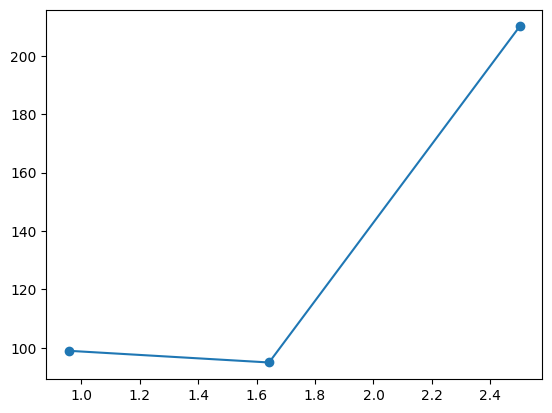

In [8]:
plt.plot(np.sort(no_opt_bonds), np.array(no_opt_K_overlap)[np.argsort(no_opt_bonds)],
        "o-", label="Canonical orbitals")

plt.plot(np.sort(matching_opt_bonds), 
         np.array(matching_opt_K_overlap)[np.argsort(matching_opt_bonds)],
        "s-", label="Matching graph")

plt.plot(np.sort(ring_opt_bonds), 
         np.array(ring_opt_K_overlap)[np.argsort(ring_opt_bonds)],
        "v-", label="Ring graph")

plt.xlabel("bond length, A")
plt.ylabel(r"$K_{overlap}$")
plt.legend(fontsize=12)
# plt.savefig("../plots/K_overlap_" + hamiltonian_class + ".png",
#            dpi=400, bbox_inches="tight")
plt.show()

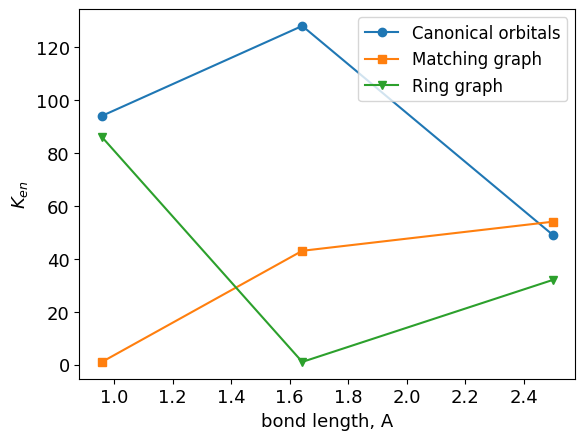

In [107]:
plt.plot(np.sort(no_opt_bonds), np.array(no_opt_K_en)[np.argsort(no_opt_bonds)],
        "o-", label="Canonical orbitals")

plt.plot(np.sort(matching_opt_bonds), 
         np.array(matching_opt_K_en)[np.argsort(matching_opt_bonds)],
        "s-", label="Matching graph")

plt.plot(np.sort(ring_opt_bonds), 
         np.array(ring_opt_K_en)[np.argsort(ring_opt_bonds)],
        "v-", label="Ring graph")

plt.xlabel("bond length, A")
plt.ylabel(r"$K_{en}$")
plt.legend(fontsize=12)
plt.savefig("../plots/K_en_" + hamiltonian_class + ".png",
           dpi=400, bbox_inches="tight")
plt.show()

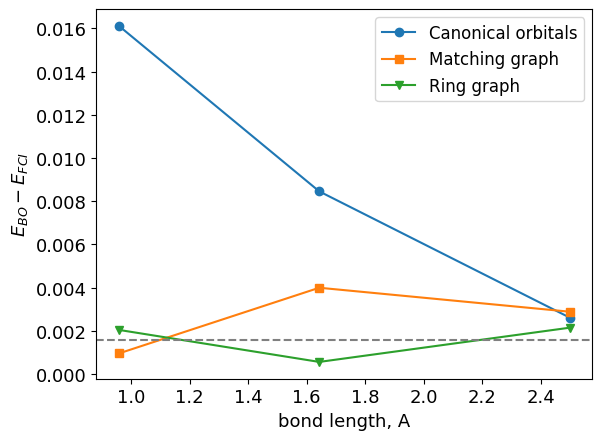

In [108]:
plt.plot(np.sort(no_opt_bonds), no_opt_bo_ens - fci_ens,
        "o-", label="Canonical orbitals")

plt.plot(np.sort(matching_opt_bonds), 
         matching_opt_bo_ens - fci_ens,
        "s-", label="Matching graph")

plt.plot(np.sort(ring_opt_bonds), 
         ring_opt_bo_ens - fci_ens,
        "v-", label="Ring graph")

plt.axhline(0.0016, linestyle="--", color="gray")

plt.xlabel("bond length, A")
plt.ylabel(r"$E_{BO} - E_{FCI}$")
plt.legend(fontsize=12)
plt.savefig("../plots/dE_BO_" + hamiltonian_class + ".png",
           dpi=400, bbox_inches="tight")
plt.show()

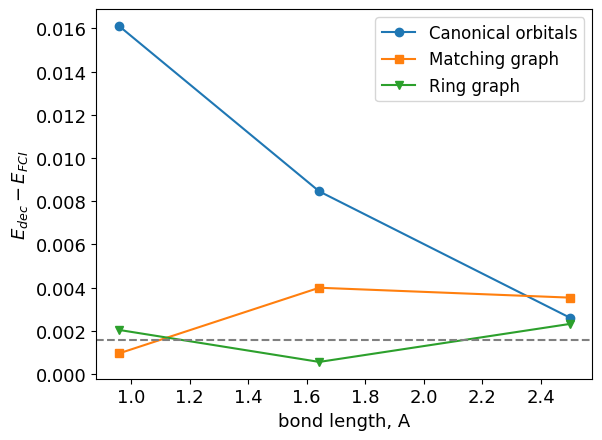

In [109]:
plt.plot(np.sort(no_opt_bonds), no_opt_decoupled_ens - fci_ens,
        "o-", label="Canonical orbitals")

plt.plot(np.sort(matching_opt_bonds), 
         matching_opt_decoupled_ens - fci_ens,
        "s-", label="Matching graph")

plt.plot(np.sort(ring_opt_bonds), 
         ring_opt_decoupled_ens - fci_ens,
        "v-", label="Ring graph")

plt.axhline(0.0016, linestyle="--", color="gray")

plt.xlabel("bond length, A")
plt.ylabel(r"$E_{dec} - E_{FCI}$")
plt.legend(fontsize=12)
plt.savefig("../plots/dE_dec_" + hamiltonian_class + ".png",
           dpi=400, bbox_inches="tight")
plt.show()